# Содержание

1. [Описание признаков датасета](#Описание-признаков-датасета)
2. [Производные признаки и удаление лишних колонок](#Производные-признаки-и-удаление-лишних-колонок)
3. [EDA: первичный анализ датасета квартир](#EDA:-первичный-анализ-датасета-квартир)
   - [Размер датасета, типы данных и первые строки](#1.-Размер-датасета,-типы-данных-и-первые-строки)
   - [Пропущенные значения](#2.-Пропущенные-значения)
   - [Проверка дубликатов](#3.-Проверка-дубликатов)
   - [Описательная статистика числовых признаков](#4.-Описательная-статистика-числовых-признаков)
   - [Распределение цены, площади и цены за квадратный метр](#5.-Распределение-цены,-площади-и-цены-за-квадратный-метр)
   - [Категориальные признаки](#6.-Категориальные-признаки)
   - [Цена по районам и типам дома](#7.-Цена-по-районам-и-типам-дома)
   - [Корреляции числовых признаков](#8.-Корреляции-числовых-признаков)
   - [Связь площади, года постройки и цены](#9.-Связь-площади,-года-постройки-и-цены)
   - [Географическое распределение объявлений](#10.-Географическое-распределение-объявлений)
   - [Выбросы по ключевым числовым признакам](#11.-Выбросы-по-ключевым-числовым-признакам)
   - [Автоматический краткий вывод по EDA](#12.-Автоматический-краткий-вывод-по-EDA)
4. [Поэтапная подготовка данных и обучение модели](#Поэтапная-подготовка-данных-и-обучение-модели)
   - [Целевая переменная](#1.-Целевая-переменная)
   - [Очистка: дубликаты, лишние колонки, очевидно странные значения](#2.-Очистка:-дубликаты,-лишние-колонки,-очевидно-странные-значения)
   - [Очистка выбросов](#3.-Очистка-выбросов)
   - [Feature Engineering](#4.-Feature-Engineering)
   - [Feature Selection](#5.-Feature-Selection)
   - [Разделение на X и y](#6.-Разделение-на-X-и-y)
   - [Train/Test Split](#7.-Train/Test-Split)
   - [Преобразования признаков: fit только на train](#8.-Преобразования-признаков:-fit-только-на-train)
   - [Обучение нескольких моделей](#9.-Обучение-нескольких-моделей)
   - [Логарифмирование target](#10.-Логарифмирование-target)
   - [Выбор лучшей модели](#11.-Выбор-лучшей-модели)
   - [Анализ ошибок лучшей модели](#12.-Анализ-ошибок-лучшей-модели)
   - [Важность признаков для RandomForest](#13.-Важность-признаков-для-RandomForest)
   - [Итог по этапам](#14.-Итог-по-этапам)
5. [Сохранение обученной модели в .pkl](#Сохранение-обученной-модели-в-.pkl)


In [46]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, skew, chi2_contingency

# from sklearn.preprocessing import StandardScaler, OrdinalEncoder
# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42


In [47]:
# Загружаем ваш файл (убедитесь, что файл лежит в той же папке, что и ноутбук)
df = pd.read_csv('astana_apartments.csv')

# Смотрим на первые 5 строк таблицы
df.head()

,id,listing_id,url,source,residential_complex_id,residential_complex_name,rooms,area,living_area,kitchen_area,...,internet,documents,offer_type,address,district,latitude,longitude,parsed_at,updated_at,is_active
0,1,691048362,https://krisha.kz/a/show/691048362?srchid=019b...,krisha.kz,NaN,Respublika,2,72.50,NaN,NaN,...,NaN,NaN,NaN,Е-36 5,Нура р-н,51.128205,71.385412,2026-01-03T20:50:46.421397,NaN,1
1,2,1004599137,https://krisha.kz/a/show/1004599137?srchid=019...,krisha.kz,NaN,Family Town,3,89.30,NaN,11.80,...,NaN,NaN,NaN,Е652 6,Есильский р-н,51.059035,71.420952,2026-01-03T20:50:52.735945,NaN,1
2,3,761512600,https://krisha.kz/a/show/761512600?srchid=019b...,krisha.kz,NaN,Свечки,2,72.10,NaN,NaN,...,NaN,NaN,NaN,Богенбай батыра 30,Сарыарка р-н,51.189164,71.356273,2026-01-03T20:51:01.431439,NaN,1
3,4,1007029481,https://krisha.kz/a/show/1007029481?srchid=019...,krisha.kz,NaN,Sezim Qala.Baqyt,4,106.77,NaN,11.13,...,NaN,NaN,NaN,Туран 55/12,Нура р-н,51.114484,71.393405,2026-01-03T20:51:09.278359,NaN,1
4,5,697845378,https://krisha.kz/a/show/697845378?srchid=019b...,krisha.kz,NaN,Boston Comfort House,2,39.00,NaN,NaN,...,NaN,NaN,NaN,"мкр Уркер, Кургальжинское шоссе 108",Нура р-н,51.121439,71.283095,2026-01-03T20:51:19.144336,NaN,1


In [48]:
astana_df = df.copy()
astana_df.head()

,id,listing_id,url,source,residential_complex_id,residential_complex_name,rooms,area,living_area,kitchen_area,...,internet,documents,offer_type,address,district,latitude,longitude,parsed_at,updated_at,is_active
0,1,691048362,https://krisha.kz/a/show/691048362?srchid=019b...,krisha.kz,NaN,Respublika,2,72.50,NaN,NaN,...,NaN,NaN,NaN,Е-36 5,Нура р-н,51.128205,71.385412,2026-01-03T20:50:46.421397,NaN,1
1,2,1004599137,https://krisha.kz/a/show/1004599137?srchid=019...,krisha.kz,NaN,Family Town,3,89.30,NaN,11.80,...,NaN,NaN,NaN,Е652 6,Есильский р-н,51.059035,71.420952,2026-01-03T20:50:52.735945,NaN,1
2,3,761512600,https://krisha.kz/a/show/761512600?srchid=019b...,krisha.kz,NaN,Свечки,2,72.10,NaN,NaN,...,NaN,NaN,NaN,Богенбай батыра 30,Сарыарка р-н,51.189164,71.356273,2026-01-03T20:51:01.431439,NaN,1
3,4,1007029481,https://krisha.kz/a/show/1007029481?srchid=019...,krisha.kz,NaN,Sezim Qala.Baqyt,4,106.77,NaN,11.13,...,NaN,NaN,NaN,Туран 55/12,Нура р-н,51.114484,71.393405,2026-01-03T20:51:09.278359,NaN,1
4,5,697845378,https://krisha.kz/a/show/697845378?srchid=019b...,krisha.kz,NaN,Boston Comfort House,2,39.00,NaN,NaN,...,NaN,NaN,NaN,"мкр Уркер, Кургальжинское шоссе 108",Нура р-н,51.121439,71.283095,2026-01-03T20:51:19.144336,NaN,1


## Описание признаков датасета

| Признак | Тип в данных | Тип признака | Что означает |
|---|---|---|---|
| `id` | `int64` | идентификатор | Внутренний номер строки/записи в датасете |
| `listing_id` | `int64` | идентификатор | ID объявления на сайте |
| `url` | `str` | текстовый/служебный | Ссылка на объявление |
| `source` | `str` | категориальный | Источник данных, здесь везде `krisha.kz` |
| `residential_complex_id` | `float64` | служебный | ID жилого комплекса, но колонка полностью пустая |
| `residential_complex_name` | `str` | категориальный | Название ЖК, например `Family Town`, `Respublika` |
| `rooms` | `int64` | числовой дискретный | Количество комнат |
| `area` | `float64` | числовой непрерывный | Общая площадь квартиры, м² |
| `living_area` | `float64` | числовой непрерывный | Жилая площадь, м² |
| `kitchen_area` | `float64` | числовой непрерывный | Площадь кухни, м² |
| `floor` | `float64` | числовой дискретный | Этаж квартиры |
| `total_floors` | `float64` | числовой дискретный | Всего этажей в доме |
| `price_usd` | `int64` | числовой непрерывный | Цена квартиры в долларах |
| `price_local` | `int64` | числовой непрерывный | Цена квартиры в местной валюте, скорее всего тенге |
| `price_per_m2` | `int64` | числовой непрерывный | Цена за 1 м² |
| `house_type` | `str` | категориальный | Тип дома: монолитный, кирпичный, панельный, иной |
| `year_built` | `int64` | числовой дискретный | Год постройки дома |
| `building_series` | `float64` | категориальный/служебный | Серия дома, но колонка полностью пустая |
| `ceiling_height` | `float64` | числовой непрерывный | Высота потолков, м |
| `condition` | `str` | категориальный | Состояние ремонта: черновая отделка, свежий ремонт и т.д. |
| `bathroom` | `str` | категориальный | Санузел: совмещенный, раздельный, 2 с/у и более, нет |
| `balcony` | `str` | категориальный | Балкон/лоджия: балкон, лоджия, несколько и т.д. |
| `parking` | `str` | категориальный | Парковка: паркинг, гараж, охраняемая стоянка |
| `furniture` | `str` | категориальный | Наличие мебели: полностью, частично, без мебели |
| `floor_type` | `str` | категориальный | Тип пола: ламинат, линолеум, паркет, плитка и т.д. |
| `heating` | `float64` | категориальный/служебный | Отопление, но колонка полностью пустая |
| `security` | `str` | категориальный/текстовый | Безопасность: охрана, домофон, видеонаблюдение, консьерж и т.д. |
| `internet` | `float64` | категориальный/служебный | Интернет, но колонка полностью пустая |
| `documents` | `float64` | категориальный/служебный | Документы, но колонка полностью пустая |
| `offer_type` | `float64` | категориальный/служебный | Тип предложения, но колонка полностью пустая |
| `address` | `str` | текстовый/категориальный | Адрес квартиры |
| `district` | `str` | категориальный | Район города: Нура, Есильский, Сарыарка и т.д. |
| `latitude` | `float64` | числовой/географический | Широта объекта |
| `longitude` | `float64` | числовой/географический | Долгота объекта |
| `parsed_at` | `str` | дата-время | Когда объявление было спарсено |
| `updated_at` | `str` | дата-время | Когда объявление обновлялось; много пропусков |
| `is_active` | `int64` | бинарный/служебный | Активно ли объявление; в данных везде значение `1` |


## Производные признаки и удаление лишних колонок

### Производные признаки, которые часто создают:

| Новый признак | Из каких признаков создается | Что означает |
|---|---|---|
| `building_age` | `year_built` | Возраст дома: текущий год минус год постройки |
| `is_new_building` | `year_built` | Признак нового дома, например если дом построен после 2020 года |
| `floor_ratio` | `floor`, `total_floors` | Относительное положение квартиры в доме: этаж / всего этажей |
| `is_first_floor` | `floor` | Находится ли квартира на первом этаже |
| `is_last_floor` | `floor`, `total_floors` | Находится ли квартира на последнем этаже |
| `has_balcony` | `balcony` | Есть ли балкон или лоджия |
| `has_parking` | `parking` | Есть ли парковка |
| `has_furniture` | `furniture` | Есть ли мебель в квартире |
| `has_security` | `security` | Есть ли элементы безопасности: охрана, домофон, видеонаблюдение и т.д. |
| `rooms_per_area` | `rooms`, `area` | Количество комнат на 1 м²; помогает оценить плотность планировки |
| `kitchen_area_ratio` | `kitchen_area`, `area` | Доля кухни от общей площади |
| `living_area_ratio` | `living_area`, `area` | Доля жилой площади от общей площади |

### Дубликаты, которые стоит удалить перед моделированием:

| Признак | Почему стоит удалить |
|---|---|
| `id` | Технический номер строки, не несет полезной информации о цене |
| `listing_id` | Уникальный ID объявления; модель может запомнить объявления вместо закономерностей |
| `url` | Ссылка на объявление, служебный текстовый признак |
| `source` | Везде одно значение `krisha.kz`, поэтому признак не помогает модели |
| `residential_complex_id` | Колонка полностью пустая |
| `building_series` | Колонка полностью пустая |
| `heating` | Колонка полностью пустая |
| `internet` | Колонка полностью пустая |
| `documents` | Колонка полностью пустая |
| `offer_type` | Колонка полностью пустая |
| `is_active` | Везде одно значение `1`, поэтому признак не различает квартиры |
| `price_usd` или `price_local` | Если целевая переменная цена, нельзя использовать другую версию цены как входной признак, иначе будет утечка данных |
| `price_per_m2` | Производная от цены и площади; при прогнозировании цены обычно вызывает утечку данных |


## EDA: первичный анализ датасета квартир

В этом разделе смотрим структуру данных, пропуски, распределения, категориальные признаки, выбросы и связи признаков с ценой.

### 1. Размер датасета, типы данных и первые строки

In [49]:
# Создаем рабочую копию датасета для EDA
astana_df = df.copy()

print(f'Количество строк: {astana_df.shape[0]}')
print(f'Количество столбцов: {astana_df.shape[1]}')

eda_overview = pd.DataFrame({
    'column': astana_df.columns,
    'dtype': astana_df.dtypes.astype(str).values,
    'non_null': astana_df.notna().sum().values,
    'missing': astana_df.isna().sum().values,
    'unique_values': astana_df.nunique(dropna=True).values
})

eda_overview

Количество строк: 18388
Количество столбцов: 37


,column,dtype,non_null,missing,unique_values
0,id,int64,18388,0,18388
1,listing_id,int64,18388,0,18388
2,url,str,18388,0,18388
3,source,str,18388,0,1
4,residential_complex_id,float64,0,18388,0
5,residential_complex_name,str,14495,3893,1185
6,rooms,int64,18388,0,12
7,area,float64,18388,0,2139
8,living_area,float64,82,18306,69
9,kitchen_area,float64,7621,10767,646


### 2. Пропущенные значения

Смотрим, какие признаки содержат много пропусков. Колонки со 100% пропусков обычно удаляют перед моделированием.

In [50]:
missing_df = (
    astana_df.isna().sum()
    .to_frame('missing_count')
    .assign(missing_percent=lambda x: (x['missing_count'] / len(astana_df) * 100).round(2))
    .sort_values('missing_percent', ascending=False)
)

missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_percent
heating,18388,100.00
building_series,18388,100.00
internet,18388,100.00
offer_type,18388,100.00
documents,18388,100.00
residential_complex_id,18388,100.00
living_area,18306,99.55
updated_at,14838,80.69
condition,10887,59.21
kitchen_area,10767,58.55


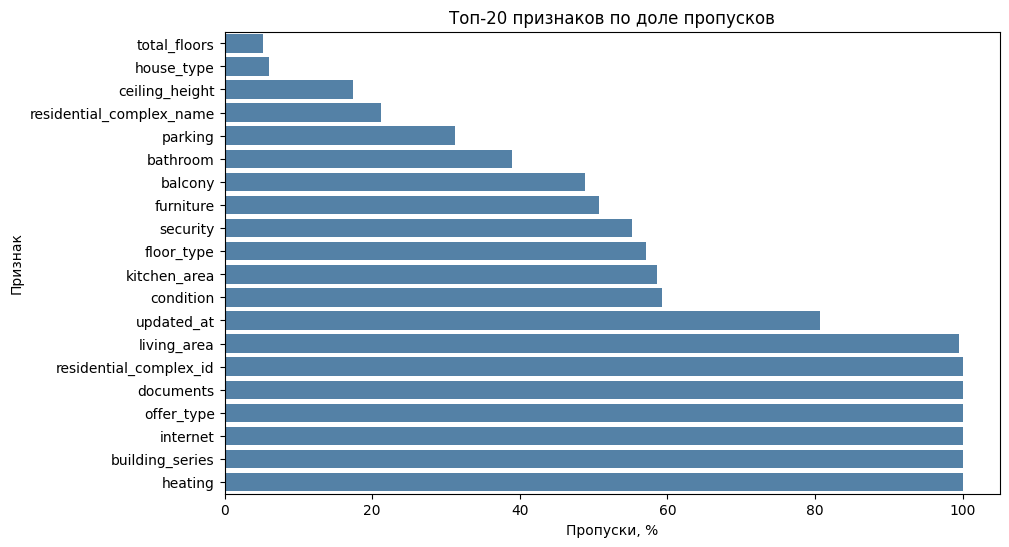

In [51]:
plt.figure(figsize=(10, 6))
missing_plot = missing_df[missing_df['missing_count'] > 0].head(20).sort_values('missing_percent')
sns.barplot(data=missing_plot, x='missing_percent', y=missing_plot.index, color='steelblue')
plt.title('Топ-20 признаков по доле пропусков')
plt.xlabel('Пропуски, %')
plt.ylabel('Признак')
plt.show()

### 3. Проверка дубликатов

Проверяем полные дубликаты строк и дубликаты по ID объявления.

In [52]:
print(f'Полные дубликаты строк: {astana_df.duplicated().sum()}')
print(f'Дубликаты listing_id: {astana_df.duplicated(subset=["listing_id"]).sum()}')
print(f'Дубликаты url: {astana_df.duplicated(subset=["url"]).sum()}')

Полные дубликаты строк: 0
Дубликаты listing_id: 0
Дубликаты url: 0


### 4. Описательная статистика числовых признаков

In [53]:
numeric_cols = astana_df.select_dtypes(include=['number']).columns.tolist()

astana_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
id,18388.0,9.194500e+03,5.308303e+03,1.000000e+00,4.597750e+03,9.194500e+03,1.379125e+04,1.838800e+04
listing_id,18388.0,9.725041e+08,1.005727e+08,1.940254e+07,1.005556e+09,1.007650e+09,1.008192e+09,1.008408e+09
residential_complex_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rooms,18388.0,2.317762e+00,1.041853e+00,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,1.300000e+01
area,18388.0,7.304792e+01,4.169170e+01,1.080000e+01,4.370000e+01,6.300000e+01,9.000000e+01,5.564000e+02
living_area,82.0,7.127012e+01,4.365031e+01,1.880000e+01,4.162500e+01,6.000000e+01,8.600000e+01,2.852000e+02
kitchen_area,7621.0,1.312213e+01,1.068263e+01,1.200000e+00,1.000000e+01,1.200000e+01,1.500000e+01,7.070000e+02
floor,17417.0,6.767526e+00,4.329900e+00,1.000000e+00,3.000000e+00,6.000000e+00,9.000000e+00,4.100000e+01
total_floors,17417.0,1.156175e+01,5.109851e+00,2.000000e+00,9.000000e+00,1.000000e+01,1.400000e+01,4.300000e+01
price_usd,18388.0,9.395154e+04,8.081485e+04,7.840000e+03,5.010700e+04,7.073900e+04,1.080740e+05,2.947475e+06


### 5. Распределение цены, площади и цены за квадратный метр

Для графиков дополнительно ограничиваем очень дорогие объекты 99-м перцентилем, чтобы основная масса данных была видна лучше.

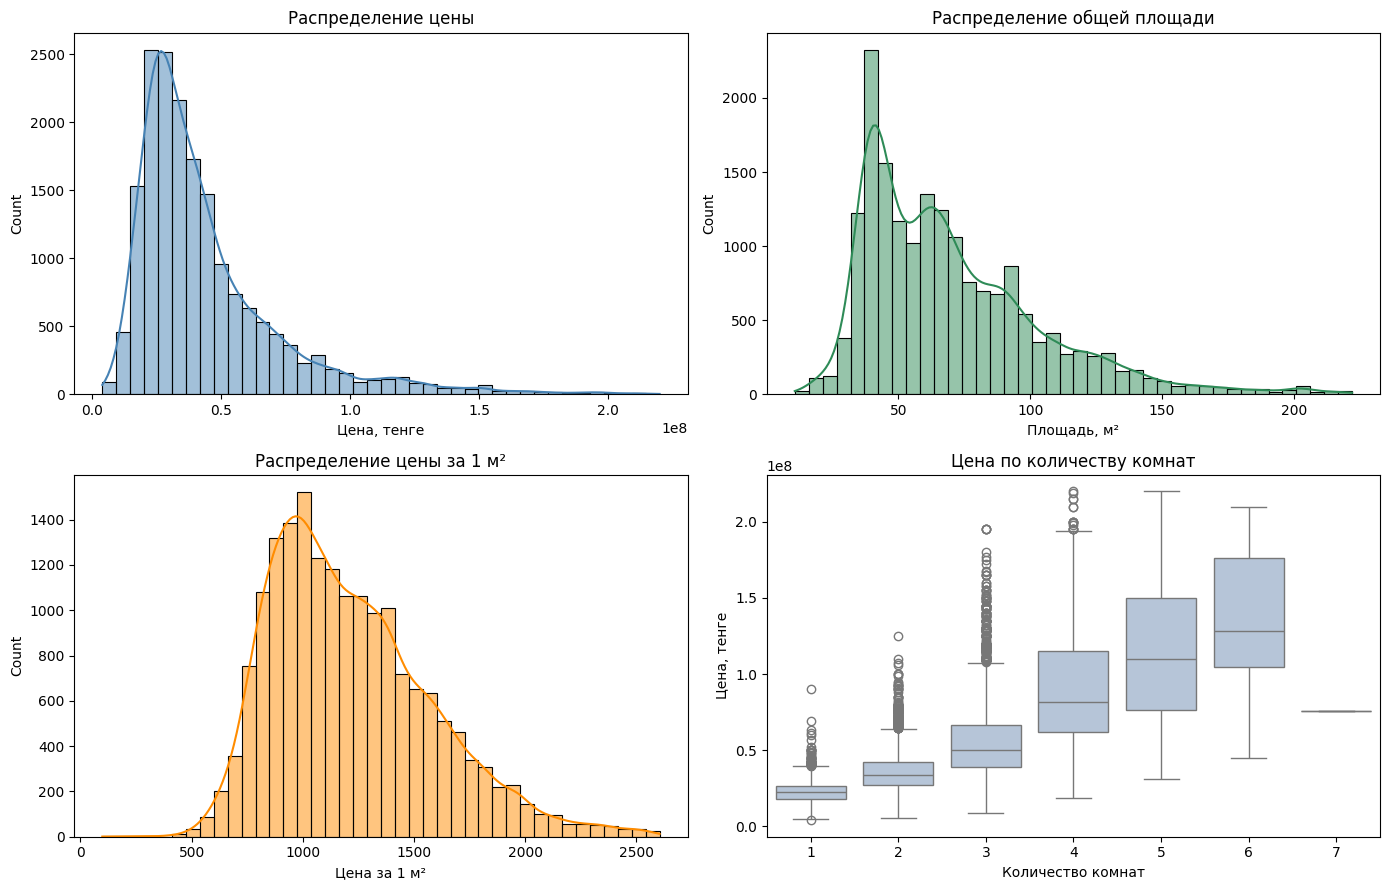

In [54]:
price_limit = astana_df['price_local'].quantile(0.99)
area_limit = astana_df['area'].quantile(0.99)
pm2_limit = astana_df['price_per_m2'].quantile(0.99)

plot_df = astana_df[
    (astana_df['price_local'] <= price_limit) &
    (astana_df['area'] <= area_limit) &
    (astana_df['price_per_m2'] <= pm2_limit)
].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(plot_df['price_local'], bins=40, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Распределение цены')
axes[0, 0].set_xlabel('Цена, тенге')

sns.histplot(plot_df['area'], bins=40, kde=True, ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title('Распределение общей площади')
axes[0, 1].set_xlabel('Площадь, м²')

sns.histplot(plot_df['price_per_m2'], bins=40, kde=True, ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('Распределение цены за 1 м²')
axes[1, 0].set_xlabel('Цена за 1 м²')

sns.boxplot(data=plot_df, x='rooms', y='price_local', ax=axes[1, 1], color='lightsteelblue')
axes[1, 1].set_title('Цена по количеству комнат')
axes[1, 1].set_xlabel('Количество комнат')
axes[1, 1].set_ylabel('Цена, тенге')

plt.tight_layout()
plt.show()

### 6. Категориальные признаки

Смотрим самые частые значения в основных категориальных колонках.

In [55]:
categorical_cols = astana_df.select_dtypes(include=['object', 'string']).columns.tolist()

for col in ['house_type', 'condition', 'bathroom', 'balcony', 'parking', 'furniture', 'floor_type', 'district']:
    print(f'\n{col}')
    display(astana_df[col].value_counts(dropna=False).head(10).to_frame('count'))


house_type


,count
house_type,
монолитный,9515
кирпичный,6776
NaN,1117
панельный,716
иной,264



condition


,count
condition,
NaN,10887
свежий ремонт,3866
"не новый, но аккуратный ремонт",2029
черновая отделка,1256
требует ремонта,260
свободная планировка,90



bathroom


...

,count
furniture,
NaN,9323
полностью,6171
частично,2136
без мебели,758



floor_type


,count
floor_type,
NaN,10501
ламинат,6475
линолеум,719
паркет,604
плитка,44
дерево,25
пробковый,18
ковролан,2



district


,count
district,
Есильский р-н,5121
Нура р-н,4123
Алматы р-н,3894
Сарыарка р-н,2104
Сарайшык р-н,1467
р-н Байконур,901
NaN,778


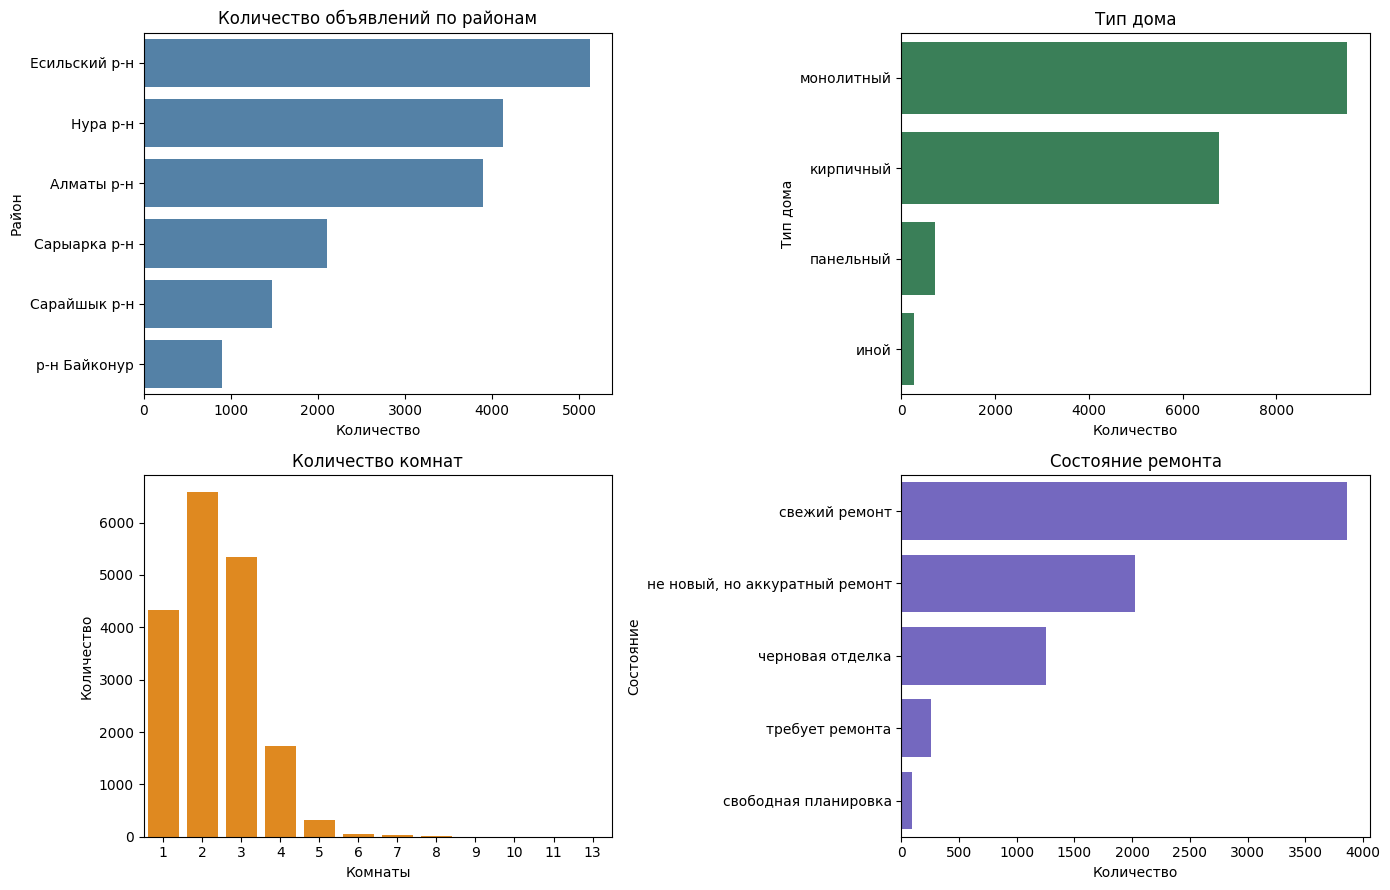

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.countplot(data=astana_df, y='district', order=astana_df['district'].value_counts().index, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Количество объявлений по районам')
axes[0, 0].set_xlabel('Количество')
axes[0, 0].set_ylabel('Район')

sns.countplot(data=astana_df, y='house_type', order=astana_df['house_type'].value_counts().index, ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title('Тип дома')
axes[0, 1].set_xlabel('Количество')
axes[0, 1].set_ylabel('Тип дома')

sns.countplot(data=astana_df, x='rooms', order=sorted(astana_df['rooms'].dropna().unique()), ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('Количество комнат')
axes[1, 0].set_xlabel('Комнаты')
axes[1, 0].set_ylabel('Количество')

sns.countplot(data=astana_df, y='condition', order=astana_df['condition'].value_counts().index, ax=axes[1, 1], color='slateblue')
axes[1, 1].set_title('Состояние ремонта')
axes[1, 1].set_xlabel('Количество')
axes[1, 1].set_ylabel('Состояние')

plt.tight_layout()
plt.show()

### 7. Цена по районам и типам дома

In [57]:
district_price = (
    astana_df.groupby('district', dropna=False)
    .agg(
        listings=('price_local', 'size'),
        median_price=('price_local', 'median'),
        median_price_per_m2=('price_per_m2', 'median'),
        median_area=('area', 'median')
    )
    .sort_values('median_price', ascending=False)
)

district_price

,listings,median_price,median_price_per_m2,median_area
district,,,,
Есильский р-н,5121,49990000.0,1390.0,73.0
NaN,778,41500000.0,1240.0,68.0
Нура р-н,4123,37000000.0,1309.0,60.0
Сарайшык р-н,1467,31999000.0,1129.0,58.0
Алматы р-н,3894,30500000.0,1004.0,63.0
р-н Байконур,901,30000000.0,895.0,64.0
Сарыарка р-н,2104,25300000.0,926.0,52.0


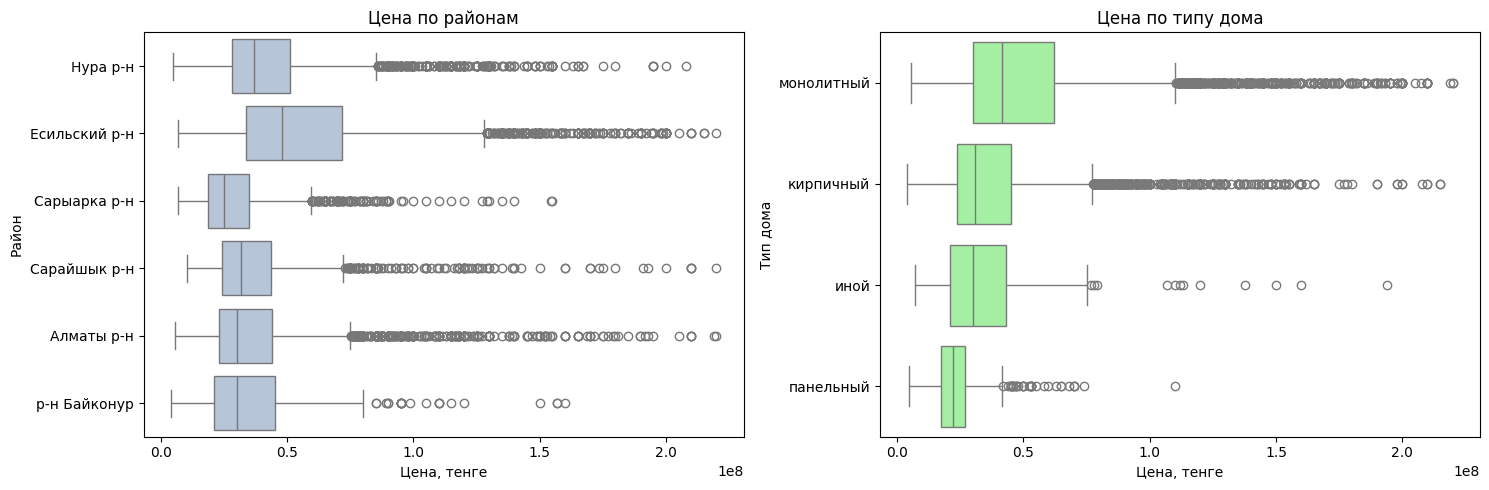

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=plot_df, y='district', x='price_local', ax=axes[0], color='lightsteelblue')
axes[0].set_title('Цена по районам')
axes[0].set_xlabel('Цена, тенге')
axes[0].set_ylabel('Район')

sns.boxplot(data=plot_df, y='house_type', x='price_local', ax=axes[1], color='palegreen')
axes[1].set_title('Цена по типу дома')
axes[1].set_xlabel('Цена, тенге')
axes[1].set_ylabel('Тип дома')

plt.tight_layout()
plt.show()

### 8. Корреляции числовых признаков

Корреляция помогает увидеть линейные связи между числовыми признаками и ценой.

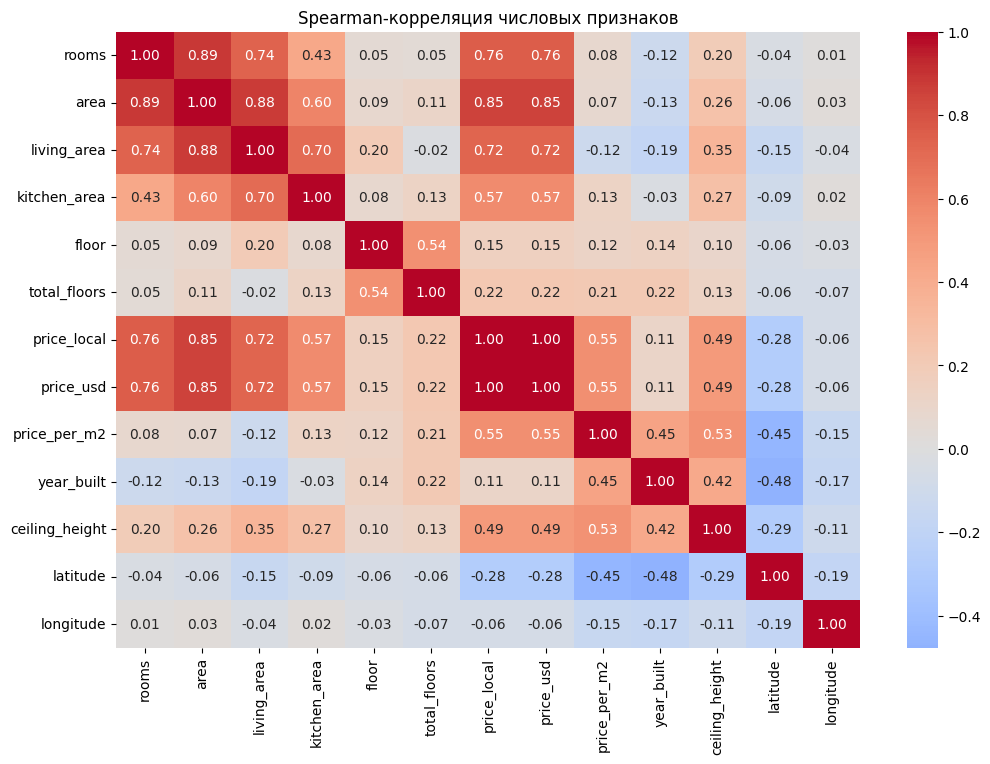

,corr_with_price_local
price_local,1.000000
price_usd,1.000000
area,0.850282
rooms,0.761544
living_area,0.723326
kitchen_area,0.566145
price_per_m2,0.551113
ceiling_height,0.493070
total_floors,0.223650
floor,0.147576


In [59]:
corr_cols = [
    'rooms', 'area', 'living_area', 'kitchen_area', 'floor', 'total_floors',
    'price_local', 'price_usd', 'price_per_m2', 'year_built', 'ceiling_height',
    'latitude', 'longitude'
]
corr_cols = [col for col in corr_cols if col in astana_df.columns]

corr_matrix = astana_df[corr_cols].corr(method='spearman')

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Spearman-корреляция числовых признаков')
plt.show()

corr_matrix['price_local'].sort_values(ascending=False).to_frame('corr_with_price_local')

### 9. Связь площади, года постройки и цены

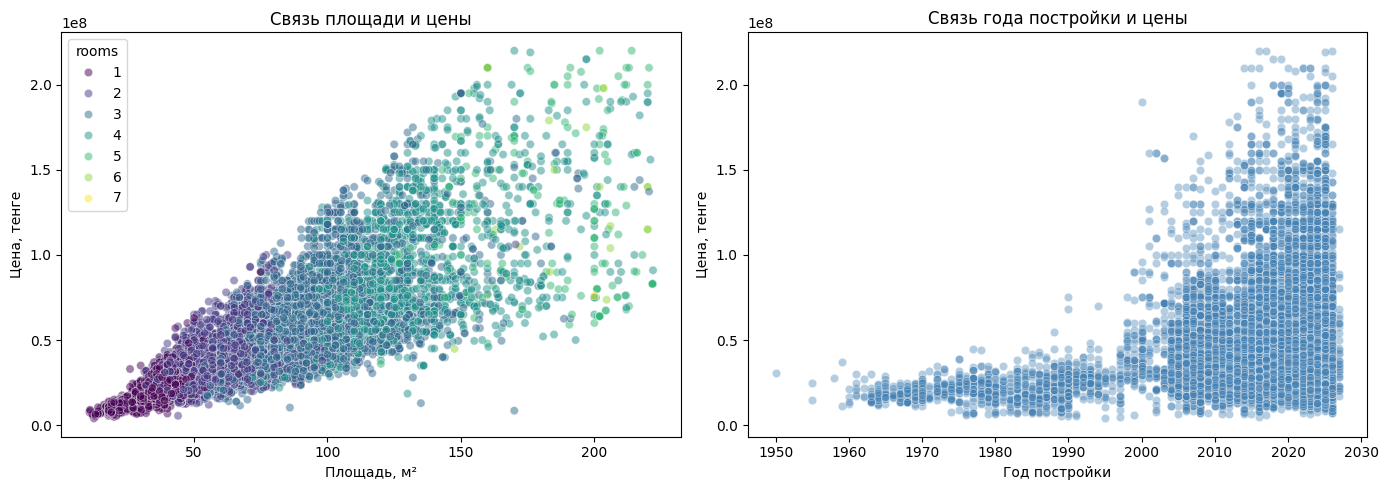

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=plot_df, x='area', y='price_local', hue='rooms', palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title('Связь площади и цены')
axes[0].set_xlabel('Площадь, м²')
axes[0].set_ylabel('Цена, тенге')

sns.scatterplot(data=plot_df, x='year_built', y='price_local', alpha=0.4, ax=axes[1], color='steelblue')
axes[1].set_title('Связь года постройки и цены')
axes[1].set_xlabel('Год постройки')
axes[1].set_ylabel('Цена, тенге')

plt.tight_layout()
plt.show()

### 10. Географическое распределение объявлений

Точки показывают координаты квартир, цвет — цену за квадратный метр.

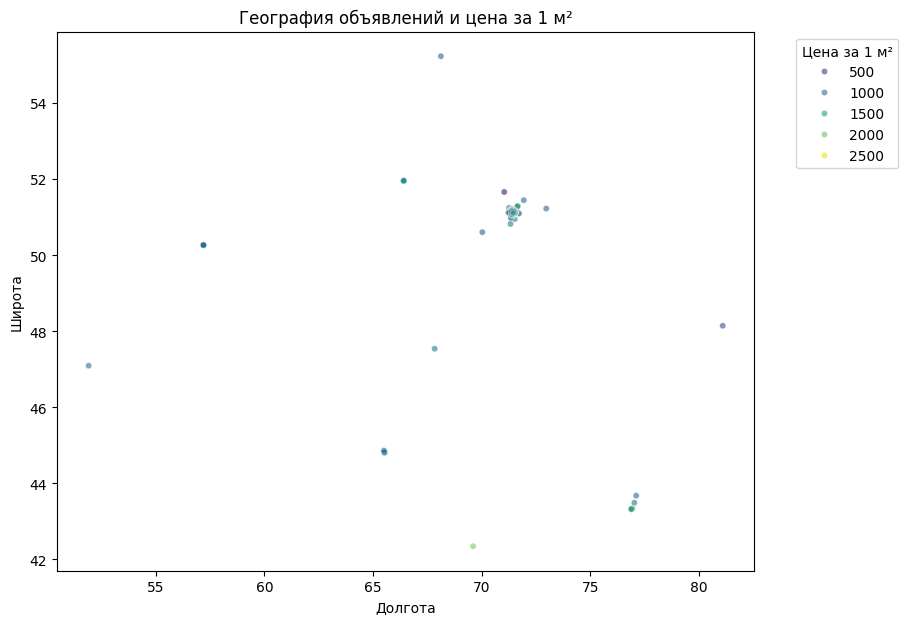

In [61]:
geo_df = astana_df.dropna(subset=['latitude', 'longitude', 'price_per_m2']).copy()
geo_df = geo_df[geo_df['price_per_m2'] <= geo_df['price_per_m2'].quantile(0.99)]

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=geo_df,
    x='longitude',
    y='latitude',
    hue='price_per_m2',
    palette='viridis',
    alpha=0.6,
    s=20
)
plt.title('География объявлений и цена за 1 м²')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.legend(title='Цена за 1 м²', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 11. Выбросы по ключевым числовым признакам

In [62]:
outlier_cols = ['price_local', 'price_usd', 'price_per_m2', 'area', 'rooms', 'year_built', 'ceiling_height']
outlier_cols = [col for col in outlier_cols if col in astana_df.columns]

outlier_summary = []
for col in outlier_cols:
    q1 = astana_df[col].quantile(0.25)
    q3 = astana_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((astana_df[col] < lower) | (astana_df[col] > upper)).sum()
    outlier_summary.append({
        'column': col,
        'min': astana_df[col].min(),
        'q1': q1,
        'median': astana_df[col].median(),
        'q3': q3,
        'max': astana_df[col].max(),
        'iqr_outliers': outliers,
        'outlier_percent': round(outliers / len(astana_df) * 100, 2)
    })

pd.DataFrame(outlier_summary)

,column,min,q1,median,q3,max,iqr_outliers,outlier_percent
0,price_local,3990000.0,25500000.0,36000000.0,55000000.0,1.500000e+09,1381,7.51
1,price_usd,7840.0,50107.0,70739.0,108074.0,2.947475e+06,1381,7.51
2,price_per_m2,98.0,944.0,1161.0,1448.0,8.421000e+03,499,2.71
3,area,10.8,43.7,63.0,90.0,5.564000e+02,678,3.69
4,rooms,1.0,2.0,2.0,3.0,1.300000e+01,406,2.21
5,year_built,1950.0,2013.0,2020.0,2024.0,2.028000e+03,1106,6.01
6,ceiling_height,2.0,2.7,3.0,3.0,2.800000e+01,86,0.47


### 12. Автоматический краткий вывод по EDA

In [63]:
print('Краткие выводы:')
print(f'- В датасете {astana_df.shape[0]} строк и {astana_df.shape[1]} признаков.')
print(f'- Полных дубликатов строк: {astana_df.duplicated().sum()}.')
print(f'- Медианная цена: {astana_df["price_local"].median():,.0f} тенге.')
print(f'- Медианная площадь: {astana_df["area"].median():.1f} м².')
print(f'- Медианная цена за 1 м²: {astana_df["price_per_m2"].median():,.0f}.')
print(f'- Самый частый район: {astana_df["district"].mode(dropna=True).iloc[0]}.')
print(f'- Самый частый тип дома: {astana_df["house_type"].mode(dropna=True).iloc[0]}.')
print('- Колонки с 100% пропусков лучше удалить перед моделированием.')
print('- price_usd, price_local и price_per_m2 нельзя одновременно использовать как признаки при прогнозировании цены, чтобы не получить утечку данных.')

Краткие выводы:
- В датасете 18388 строк и 37 признаков.
- Полных дубликатов строк: 0.
- Медианная цена: 36,000,000 тенге.
- Медианная площадь: 63.0 м².
- Медианная цена за 1 м²: 1,161.
- Самый частый район: Есильский р-н.
- Самый частый тип дома: монолитный.
- Колонки с 100% пропусков лучше удалить перед моделированием.
- price_usd, price_local и price_per_m2 нельзя одновременно использовать как признаки при прогнозировании цены, чтобы не получить утечку данных.


## Конец EDA

## Поэтапная подготовка данных и обучение модели

Дальше идем по схеме: очистка, создание новых признаков, кодирование категорий, отбор признаков, разделение на `X` и `y`, train/test split, преобразования только на train и обучение моделей.

### 1. Целевая переменная

Будем прогнозировать `price_local` — цену квартиры в тенге. `price_usd` и `price_per_m2` нельзя использовать как входные признаки, потому что они напрямую связаны с ценой и дадут утечку данных.

In [64]:
target = 'price_local'

model_df = df.copy()
print(model_df.shape)
model_df[[target, 'price_usd', 'price_per_m2', 'area', 'rooms']].head()

(18388, 37)


,price_local,price_usd,price_per_m2,area,rooms
0,38497500,75646,1043,72.50,2
1,45000000,88424,990,89.30,3
2,29000000,56984,790,72.10,2
3,76000000,149338,1398,106.77,4
4,14000000,27509,705,39.00,2


### 2. Очистка: дубликаты, лишние колонки, очевидно странные значения

На этом шаге удаляем технические признаки, полностью пустые колонки, признаки с утечкой и записи с невозможными значениями.

In [65]:
# 2.1. Удаляем полные дубликаты строк
model_df = model_df.drop_duplicates().copy()

# 2.2. Удаляем технические, пустые и leakage-колонки
cols_to_drop = [
    'id', 'listing_id', 'url', 'source',
    'residential_complex_id', 'building_series',
    'heating', 'internet', 'documents', 'offer_type',
    'is_active',
    'price_usd', 'price_per_m2',
    'parsed_at', 'updated_at'
]

model_df = model_df.drop(columns=[col for col in cols_to_drop if col in model_df.columns])

# 2.3. Удаляем строки без target и с невозможными значениями
model_df = model_df.dropna(subset=[target])
model_df = model_df[model_df[target] > 0]
model_df = model_df[model_df['area'] > 0]
model_df = model_df[model_df['rooms'] > 0]

print(model_df.shape)
model_df.head()

(18388, 22)


,residential_complex_name,rooms,area,living_area,kitchen_area,floor,total_floors,price_local,house_type,year_built,...,bathroom,balcony,parking,furniture,floor_type,security,address,district,latitude,longitude
0,Respublika,2,72.50,NaN,NaN,NaN,NaN,38497500,монолитный,2023,...,совмещенный,NaN,NaN,NaN,NaN,NaN,Е-36 5,Нура р-н,51.128205,71.385412
1,Family Town,3,89.30,NaN,11.80,4.0,5.0,45000000,кирпичный,2014,...,2 с/у и более,балкон и лоджия,паркинг,полностью,ламинат,NaN,Е652 6,Есильский р-н,51.059035,71.420952
2,Свечки,2,72.10,NaN,NaN,NaN,NaN,29000000,монолитный,1998,...,2 с/у и более,лоджия,NaN,полностью,ламинат,"видеонаблюдение, видеодомофон, консьерж",Богенбай батыра 30,Сарыарка р-н,51.189164,71.356273
3,Sezim Qala.Baqyt,4,106.77,NaN,11.13,8.0,9.0,76000000,монолитный,2023,...,NaN,NaN,паркинг,NaN,NaN,NaN,Туран 55/12,Нура р-н,51.114484,71.393405
4,Boston Comfort House,2,39.00,NaN,NaN,2.0,2.0,14000000,кирпичный,2021,...,совмещенный,лоджия,паркинг,NaN,ламинат,"охрана, домофон, кодовый замок","мкр Уркер, Кургальжинское шоссе 108",Нура р-н,51.121439,71.283095


### 3. Очистка выбросов

Для первого baseline-моделирования уберем крайние 1% по цене, площади и цене за квадратный метр. Это делает модель стабильнее и графики/метрики менее зависимыми от очень редких объектов.

In [66]:
# price_per_m2 уже удален из model_df, поэтому считаем временный показатель для фильтра выбросов
model_df['tmp_price_per_m2'] = model_df[target] / model_df['area']

price_low, price_high = model_df[target].quantile([0.01, 0.99])
area_low, area_high = model_df['area'].quantile([0.01, 0.99])
pm2_low, pm2_high = model_df['tmp_price_per_m2'].quantile([0.01, 0.99])

before_rows = len(model_df)
model_df = model_df[
    model_df[target].between(price_low, price_high) &
    model_df['area'].between(area_low, area_high) &
    model_df['tmp_price_per_m2'].between(pm2_low, pm2_high)
].copy()
model_df = model_df.drop(columns='tmp_price_per_m2')

after_rows = len(model_df)
print(f'Было строк: {before_rows}')
print(f'Осталось строк: {after_rows}')
print(f'Удалено строк: {before_rows - after_rows}')

Было строк: 18388
Осталось строк: 17608
Удалено строк: 780


### 4. Feature Engineering

Создаем новые признаки из уже существующих колонок: возраст дома, положение этажа, первый/последний этаж, наличие балкона, парковки, мебели и безопасности.

In [67]:
current_year = 2026

model_df['building_age'] = current_year - model_df['year_built']
model_df['floor_ratio'] = model_df['floor'] / model_df['total_floors']
model_df['is_first_floor'] = (model_df['floor'] == 1).astype(int)
model_df['is_last_floor'] = (model_df['floor'] == model_df['total_floors']).astype(int)

model_df['has_balcony'] = model_df['balcony'].notna().astype(int)
model_df['has_parking'] = model_df['parking'].notna().astype(int)
model_df['has_furniture'] = model_df['furniture'].notna().astype(int)
model_df['has_security'] = model_df['security'].notna().astype(int)

model_df['rooms_per_area'] = model_df['rooms'] / model_df['area']
model_df['kitchen_area_ratio'] = model_df['kitchen_area'] / model_df['area']
model_df['living_area_ratio'] = model_df['living_area'] / model_df['area']

# Если total_floors отсутствует, floor_ratio может быть NaN — позже это заполнит SimpleImputer.
model_df.replace([np.inf, -np.inf], np.nan, inplace=True)

model_df[[
    'building_age', 'floor_ratio', 'is_first_floor', 'is_last_floor',
    'has_balcony', 'has_parking', 'has_furniture', 'has_security',
    'rooms_per_area', 'kitchen_area_ratio', 'living_area_ratio'
]].head()

,building_age,floor_ratio,is_first_floor,is_last_floor,has_balcony,has_parking,has_furniture,has_security,rooms_per_area,kitchen_area_ratio,living_area_ratio
0,3,NaN,0,0,0,0,0,0,0.027586,NaN,NaN
1,12,0.800000,0,0,1,1,1,0,0.033595,0.132139,NaN
2,28,NaN,0,0,1,0,1,1,0.027739,NaN,NaN
3,3,0.888889,0,0,0,1,0,0,0.037464,0.104243,NaN
4,5,1.000000,0,1,1,1,0,1,0.051282,NaN,NaN


### 5. Feature Selection

Убираем признаки, которые слишком текстовые или могут создавать слишком много категорий. Для baseline оставляем понятные числовые и категориальные признаки.

In [68]:
# address часто почти уникальный, поэтому для первого baseline лучше убрать.
# residential_complex_name можно оставить, но у него много уникальных значений; для устойчивого baseline тоже уберем.
high_cardinality_cols = ['address', 'residential_complex_name']
model_df = model_df.drop(columns=[col for col in high_cardinality_cols if col in model_df.columns])

# Удалим признаки, из которых мы уже сделали бинарные флаги, чтобы не раздувать one-hot encoding.
replaced_by_flags = ['balcony', 'parking', 'furniture', 'security']
model_df = model_df.drop(columns=[col for col in replaced_by_flags if col in model_df.columns])

print(model_df.shape)
print(model_df.columns.tolist())

(17608, 27)
['rooms', 'area', 'living_area', 'kitchen_area', 'floor', 'total_floors', 'price_local', 'house_type', 'year_built', 'ceiling_height', 'condition', 'bathroom', 'floor_type', 'district', 'latitude', 'longitude', 'building_age', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'has_balcony', 'has_parking', 'has_furniture', 'has_security', 'rooms_per_area', 'kitchen_area_ratio', 'living_area_ratio']


### 6. Разделение на `X` и `y`

`X` — признаки квартиры, `y` — цена, которую модель должна предсказывать.

In [69]:
X = model_df.drop(columns=target)
y = model_df[target]

print('X:', X.shape)
print('y:', y.shape)

X.head()

X: (17608, 26)
y: (17608,)


,rooms,area,living_area,kitchen_area,floor,total_floors,house_type,year_built,ceiling_height,condition,...,floor_ratio,is_first_floor,is_last_floor,has_balcony,has_parking,has_furniture,has_security,rooms_per_area,kitchen_area_ratio,living_area_ratio
0,2,72.50,NaN,NaN,NaN,NaN,монолитный,2023,NaN,NaN,...,NaN,0,0,0,0,0,0,0.027586,NaN,NaN
1,3,89.30,NaN,11.80,4.0,5.0,кирпичный,2014,2.8,NaN,...,0.800000,0,0,1,1,1,0,0.033595,0.132139,NaN
2,2,72.10,NaN,NaN,NaN,NaN,монолитный,1998,2.7,"не новый, но аккуратный ремонт",...,NaN,0,0,1,0,1,1,0.027739,NaN,NaN
3,4,106.77,NaN,11.13,8.0,9.0,монолитный,2023,3.0,NaN,...,0.888889,0,0,0,1,0,0,0.037464,0.104243,NaN
4,2,39.00,NaN,NaN,2.0,2.0,кирпичный,2021,2.7,NaN,...,1.000000,0,1,1,1,0,1,0.051282,NaN,NaN


### 7. Train/Test Split

Делим данные до обучения `imputer`, `encoder` и `scaler`, чтобы не было утечки данных из test в train.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (14086, 26)
X_test: (3522, 26)
y_train: (14086,)
y_test: (3522,)


### 8. Преобразования признаков: fit только на train

Числовые признаки заполняем медианой и масштабируем. Категориальные признаки заполняем значением `unknown` и кодируем через `OneHotEncoder`. Все это находится внутри `Pipeline`.

In [71]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

print('Числовые признаки:', numeric_features)
print('Категориальные признаки:', categorical_features)

# Совместимость с разными версиями sklearn: в новых версиях sparse_output, в старых sparse.
try:
    one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', one_hot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

Числовые признаки: ['rooms', 'area', 'living_area', 'kitchen_area', 'floor', 'total_floors', 'year_built', 'ceiling_height', 'latitude', 'longitude', 'building_age', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'has_balcony', 'has_parking', 'has_furniture', 'has_security', 'rooms_per_area', 'kitchen_area_ratio', 'living_area_ratio']
Категориальные признаки: ['house_type', 'condition', 'bathroom', 'floor_type', 'district']


### 9. Обучение нескольких моделей

Сравним несколько моделей по MAE, RMSE и R². MAE показывает среднюю ошибку в тенге, поэтому его проще всего интерпретировать.

In [72]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return {
        'model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

models = {
    'Ridge': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0, random_state=SEED))
    ]),
    'RandomForest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            max_depth=18,
            min_samples_leaf=3,
            random_state=SEED,
            n_jobs=-1
        ))
    ]),
    'GradientBoosting': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(random_state=SEED))
    ])
}

results = []
trained_models = {}
for name, model in models.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(result)
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('MAE')
results_df

,model,MAE,RMSE,R2
1,RandomForest,5.088091e+06,8.918957e+06,0.904273
2,GradientBoosting,6.265832e+06,1.007666e+07,0.877808
0,Ridge,9.475147e+06,1.419494e+07,0.757520


### 10. Логарифмирование target

Цены обычно распределены скошенно. Поэтому часто помогает обучать модель не на самой цене, а на `log1p(price)`, а потом возвращать прогноз через `expm1`. Сделаем это через `TransformedTargetRegressor`.

In [73]:
log_models = {
    'Ridge_log_target': TransformedTargetRegressor(
        regressor=Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', Ridge(alpha=1.0, random_state=SEED))
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    ),
    'RandomForest_log_target': TransformedTargetRegressor(
        regressor=Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', RandomForestRegressor(
                n_estimators=200,
                max_depth=18,
                min_samples_leaf=3,
                random_state=SEED,
                n_jobs=-1
            ))
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    )
}

log_results = []
for name, model in log_models.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    log_results.append(result)
    trained_models[name] = model

all_results_df = pd.concat([results_df, pd.DataFrame(log_results)], ignore_index=True).sort_values('MAE')
all_results_df

,model,MAE,RMSE,R2
4,RandomForest_log_target,5.003378e+06,8.955027e+06,0.903497
0,RandomForest,5.088091e+06,8.918957e+06,0.904273
1,GradientBoosting,6.265832e+06,1.007666e+07,0.877808
3,Ridge_log_target,8.410886e+06,1.428306e+07,0.754500
2,Ridge,9.475147e+06,1.419494e+07,0.757520


### 11. Выбор лучшей модели

In [74]:
best_model_name = all_results_df.iloc[0]['model']
best_model = trained_models[best_model_name]

print(f'Лучшая модель по MAE: {best_model_name}')
display(all_results_df.head())

Лучшая модель по MAE: RandomForest_log_target


,model,MAE,RMSE,R2
4,RandomForest_log_target,5.003378e+06,8.955027e+06,0.903497
0,RandomForest,5.088091e+06,8.918957e+06,0.904273
1,GradientBoosting,6.265832e+06,1.007666e+07,0.877808
3,Ridge_log_target,8.410886e+06,1.428306e+07,0.754500
2,Ridge,9.475147e+06,1.419494e+07,0.757520


### 12. Анализ ошибок лучшей модели

Смотрим, где модель ошибается сильнее всего.

In [75]:
test_predictions = best_model.predict(X_test)

errors_df = X_test.copy()
errors_df['actual_price'] = y_test.values
errors_df['predicted_price'] = test_predictions
errors_df['absolute_error'] = np.abs(errors_df['actual_price'] - errors_df['predicted_price'])
errors_df['absolute_percentage_error'] = errors_df['absolute_error'] / errors_df['actual_price'] * 100

errors_df[['actual_price', 'predicted_price', 'absolute_error', 'absolute_percentage_error']].describe()

,actual_price,predicted_price,absolute_error,absolute_percentage_error
count,3.522000e+03,3.522000e+03,3.522000e+03,3522.000000
mean,4.460266e+07,4.404300e+07,5.003378e+06,10.319682
std,2.883084e+07,2.612961e+07,7.427947e+06,10.432840
min,1.200000e+07,1.234015e+07,1.961720e+02,0.000682
25%,2.600000e+07,2.662650e+07,1.021388e+06,3.104987
50%,3.550000e+07,3.594118e+07,2.684555e+06,7.462370
75%,5.300000e+07,5.313486e+07,5.958142e+06,14.320035
max,2.150000e+08,1.913386e+08,1.105621e+08,121.998426


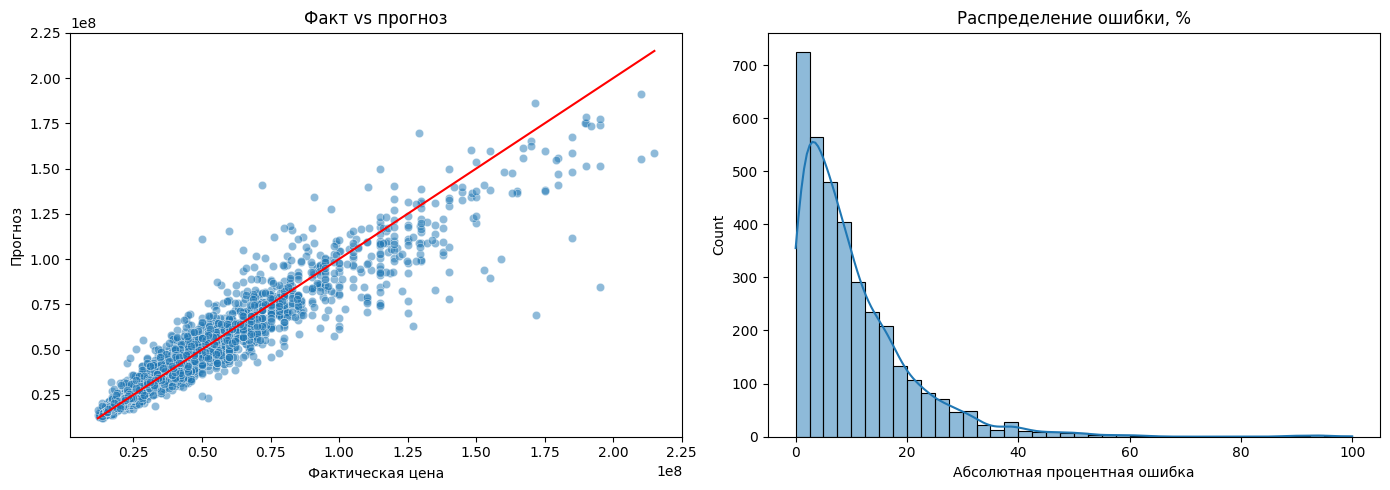

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=test_predictions, alpha=0.5, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
axes[0].set_title('Факт vs прогноз')
axes[0].set_xlabel('Фактическая цена')
axes[0].set_ylabel('Прогноз')

sns.histplot(errors_df['absolute_percentage_error'].clip(upper=100), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Распределение ошибки, %')
axes[1].set_xlabel('Абсолютная процентная ошибка')

plt.tight_layout()
plt.show()

### 13. Важность признаков для RandomForest

Если среди лучших моделей есть RandomForest, посмотрим важность признаков после one-hot encoding.

,feature,importance
1,num__area,0.748011
8,num__latitude,0.074725
9,num__longitude,0.062981
7,num__ceiling_height,0.028162
10,num__building_age,0.017935
6,num__year_built,0.015004
5,num__total_floors,0.013172
18,num__rooms_per_area,0.009862
11,num__floor_ratio,0.004972
4,num__floor,0.003334


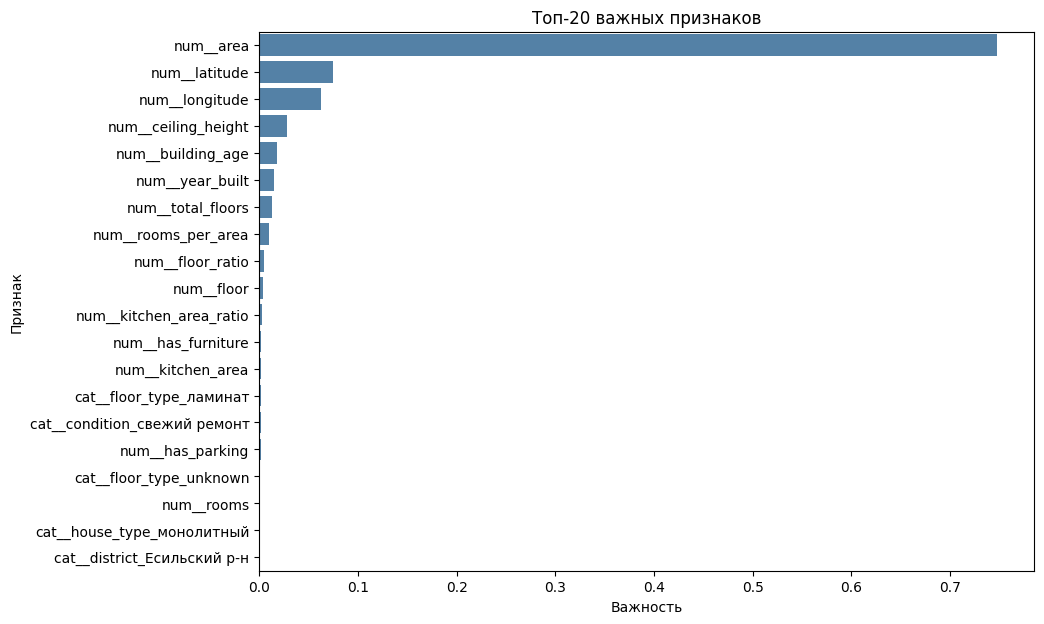

In [77]:
rf_model_name = 'RandomForest_log_target' if 'RandomForest_log_target' in trained_models else 'RandomForest'
rf_model = trained_models[rf_model_name]

# Для TransformedTargetRegressor достаем внутренний pipeline.
if hasattr(rf_model, 'regressor_'):
    rf_pipeline = rf_model.regressor_
else:
    rf_pipeline = rf_model

if hasattr(rf_pipeline.named_steps['model'], 'feature_importances_'):
    feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importances = rf_pipeline.named_steps['model'].feature_importances_
    feature_importance_df = (
        pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False)
    )
    display(feature_importance_df.head(20))

    plt.figure(figsize=(10, 7))
    sns.barplot(data=feature_importance_df.head(20), x='importance', y='feature', color='steelblue')
    plt.title('Топ-20 важных признаков')
    plt.xlabel('Важность')
    plt.ylabel('Признак')
    plt.show()
else:
    print('У выбранной модели нет feature_importances_.')

### 14. Итог по этапам

После этого блока данные полностью готовы к обучению, а baseline-модель уже обучена. Дальше можно улучшать качество: аккуратнее работать с выбросами, добавлять географические признаки, пробовать CatBoost/LightGBM/XGBoost и подбирать гиперпараметры.

In [78]:
print('Готово по схеме:')
print('1. Загрузка данных — сделано')
print('2. EDA — сделано')
print('3a. Очистка — сделано')
print('3b. Feature Engineering — сделано')
print('4. Encoding категорий — сделано внутри Pipeline')
print('5. Feature Selection — сделано базовое удаление лишних признаков')
print('6. Разделение X и y — сделано')
print('7. Train/Test Split — сделано')
print('8. Преобразования fit только на train — сделано внутри Pipeline')
print(f'Лучшая модель: {best_model_name}')
print(f'Лучший MAE: {all_results_df.iloc[0]["MAE"]:,.0f} тенге')

Готово по схеме:
1. Загрузка данных — сделано
2. EDA — сделано
3a. Очистка — сделано
3b. Feature Engineering — сделано
4. Encoding категорий — сделано внутри Pipeline
5. Feature Selection — сделано базовое удаление лишних признаков
6. Разделение X и y — сделано
7. Train/Test Split — сделано
8. Преобразования fit только на train — сделано внутри Pipeline
Лучшая модель: RandomForest_log_target
Лучший MAE: 5,003,378 тенге


## Конец поэтапного блока

## Сохранение обученной модели в .pkl

In [79]:
import joblib

joblib.dump(trained_models['RandomForest_log_target'], 'randomforest_log_target.pkl')
print('Модель сохранена: randomforest_log_target.pkl')

Модель сохранена: randomforest_log_target.pkl
